In [13]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [14]:

#fl129=pd.read_csv('paola_flares1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
#df = pd.DataFrame(fl129)
tf = pd.DataFrame(tess_f)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [15]:
#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 


#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4


###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)

In [16]:
flux_flare1 = np.array([1.00021102, 1.00016091, 1.00061244, 1.00089119, 1.00044821, 1.00071017, 1.00389754, 1.00723177, 1.0080779, 1.00589569, 1.00494147, 1.00380646, 1.00319223, 1.00332173, 1.00226165, 1.00201653, 1.00156748, 1.00151663, 1.00171848, 1.00143235, 1.00068812, 1.00132189, 1.00048698, 1.00067838, 1.00098271, 1.00056589, 1.000441, 1.00093769, 1.00079358, 1.00029553, 0.99997456])

tempo_flare1 = np.array([1336.94716227, 1336.94855114, 1336.94994001, 1336.95132889, 1336.95271776, 1336.95410663, 1336.95549551, 1336.95688438, 1336.95827325, 1336.95966212, 1336.961051, 1336.96243987, 1336.96382874, 1336.96521761, 1336.96660649, 1336.96799536, 1336.96938423, 1336.9707731, 1336.97216198, 1336.97355085, 1336.97493972, 1336.97632859, 1336.97771747, 1336.97910634, 1336.98049521, 1336.98188409, 1336.98327296, 1336.98466183, 1336.9860507, 1336.98743958, 1336.98882845])

#flux_flare1 = np.array(fluxo_tempo3)
#tempo_flare1 = np.array(tempo_flare3) 

1.1453066058571313e+33


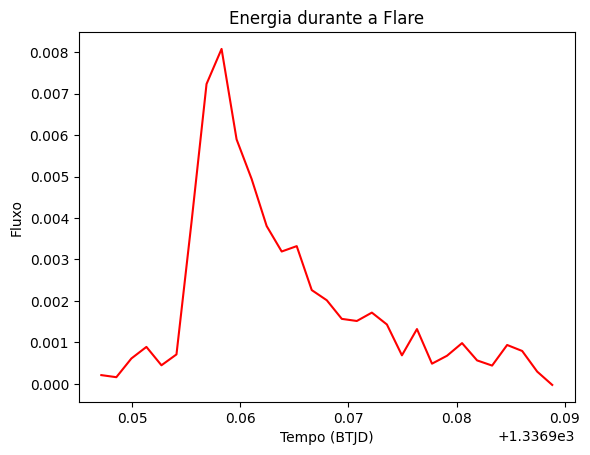

In [17]:
# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1  - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r-')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()


In [18]:
start_input = 2056.9078
stop_input = 2057.1024